# Reinforcement Learning with Q-Learning

In [54]:
import pandas as pd
import numpy as np

## Reinforcement Learning
This technique is different than many of the other machine learning techniques we have seen earlier and has many applications in training agents (an AI) to interact with environments like games. Rather than feeding our machine learning model millions of examples, we let our model come up with its own examples by exploring an environtment. The concept is fairly simple. Humans learn by exploring and lerning from mistakes and past experiences so let's have our computer do the same.

## Terminology
Before we dive into explaining reinforcement learning, we need to define a few key pieces of terminology.

**Environment** In reinforcement learning tasks we have a notion of the environment. This is what our agent will explore. An axample of an environment in the case of training an AI to play say a game of mario would be the level we are training the agent on.

**Agent** an agent is an entity that is exploring the environment. Our agent will interact and take different actions within the environment. In our mario example the mario character within the game would be our agent.

**State** at all times our agent will be in what we call a state. The state simply tells us about the status of the agent. The most common example of a state is the location of the agent within the environment. Moving locations would change the agents state.

**Action** any interaction between the agent and environment be considered an action. For example moving to the left or jumping would be an action. An action mayor may not change the current state of the agent. In fact, the act of doing nothing is actually an action as well! The action of say not pressing a key if we are using our mario example.

**Reward** every action that our agent takes will result in a reward of some magnitude (positive or negative). The goal of our agent will be to maximize its reward in an environment. Sometimes the reward will be clear, for example if an agent performs an action which increases their score in the environment we could say they've received a positive reward. If the agent were to perform an action which results in them losing score or possibly dying in the environment then they would receive a negative reward.

The most important part of reinforcement learning is determining how to reward the agent. After all, the goal of the agent is to maximize its rewards. This means we should reward the agent appropriatly such that it reaches the desired goal.

## Q-Learning
Now that we have a vague idea of how reinforcement learning works, it is time to talk about a specific technique in reinforcement learning called *Q-Learning*.

Q-Learning is a fairly simple yet quite powerful technique in machine larning that involves learning a matrix of action-reward values. This matrix is often referred to as Q-Table or Q-Matrix. The matrix is in shape (number of possible states, number of possible actions) where each value at matrix [n, m] represents the agents expected reward given they are in state n and take action m. The Q-learning algorithm defines the way we update the values in the matrix and decide what action to take at each state. The idea is that after a successful training/learning of this Q-Table/Matrix we can determine the action an agent should take in any state by looking at that states row in the matrix and taking the maximum value column as the action.

**Consider the example below**
Let's say A1-A4 are the possible actions and we have 3 states represented bu each row (state 0 - state 2)

In [13]:
table = {"A1" : [0, 5, 10], 
         "A2" : [0, 10, 5],
         "A3" : [10, 0, 0],
         "A4" : [5, 0, 0]}
pd.DataFrame(table)

,A1,A2,A3,A4
0,0,0,10,5
1,5,10,0,0
2,10,5,0,0


If that was our Q-Table/matrix then the following would be the preferred actions in each state.

- State 0: A3
- State 1: A2
- State 2: A1

We can see that this is beacuse the values in each of those columns are the highest for those states.

## Learning the Q-Table
So that's pretty simpe, right? Now, how do we create this table and find those values. We'll this is where we will discuss how the Q-Learning algorithm updates the values in our Q-Table.

I'll start by noting that our Q-Table starts of with all 0 values. This is because the agent has yet to learn anything about the environment.

Our agent learns by exploring the environment and observing the outcome/reward from each action it takes in a given state. But, how does it know what action to takes in each state? There are two ways that our agent can decide on which action to take.

1. Randomly picking a valid action
2. Using the current Q-Table to find the best action.

Near the beginning of our agents learning, it will mostly take random actions in order to explore the environment and enter many different states. As it stars to explore more of environment, it will start to gradually rely more on its learned values (Q-Table) to take actions. This means that as our agent explores more of the environment it will develop a better understanding and start to take "correct" or better actions more often. It's important that the agent has a good balance of taking random actions and using learned values to ensure it does get trapped in a local maxima.

After each new action, our agent will record the new state (if any) that it has entered and the reward that it received from taking that action. These values will be used to update the Q-Table. The agent will stop taking new actions only once a certain time limit is reached or it has achieved the goal or reached the end of the environment.

## Updating Q-Values
The formula for updating the Q-Table after each action is as follows:
$$
Q[state, action] = Q[state, action] + \alpha * (reward + \gamma * max(Q[newState, :]) - Q[state, action])
$$
- $\alpha$ stands for the **Learning Rate**
- $\gamma$ stands for **Discount Factor**

### Learning Rate $\alpha$
The learning rate $\alpha$ is a numeric constant that defines how much change is permitted on each QTable update. A high learning rate means that each update will introduce a large change to the current state-action value. A small learning rate means that each update has a more subtle change. Modifying the learning rate will change how the agent explores the environment and how quickly it determines the final values in the QTable.

### Discount Factor \gamma
Discount factor, also know as gamma ($\gamma$) is used to balance how much focus is put on the current and future reward. A high discount facor means that future rewards will be considered more heavily.

To perform updates on this table, we will let the agent explores the environment for a certain period of time and use each of its actions to make an update. Slowly, we should start to notice the agent learning and choosing better actions.

## Q-Learning Example
For this example, we will use the Q-Learning algorithm to train an agent to navigate a popular environment from the **Open AI Gym**. The Open AI Gym was developed so programmers could practice machine learning using unique environments.

In [16]:
import gym # all you have to do to import and use open ai gym!

Once you import gym you can load an environment using the line `gym.make("environment")`.

In [21]:
env = gym.make('FrozenLake-v1') # we are going to use the FrozenLake environment

There are a few other commands that can be used to interact and get information about the environment.

In [22]:
print(env.observation_space.n) # get number of states
print(env.action_space.n) # get number of actions

16
4


In [24]:
env.reset() # reset environment to default state

(0, {'prob': 1})

In [41]:
action = env.action_space.sample() # get a random action
print(action)

2


In [47]:
new_state, reward, done, truncated, info = env.step(action) # take action, notice it returns information about the action

In [67]:
print(new_state, reward, done, truncated, info)

9 0.0 False False {'prob': 0.3333333333333333}


In [53]:
env.render()

/Users/louischaristias/miniconda3/lib/python3.11/site-packages/gym/envs/toy_text/frozen_lake.py:271: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym("FrozenLake-v1", render_mode="rgb_array")
  logger.warn(


### Frozen Lake Environment
Now that we have a basic understanding of how the gym environment works, it;s time to discuss the specific problem we will be solving.

The environment we loaded above `FrozenLake-v1` is one of the most simple eenvironments in Open AI Gym. The goal of the agent is to navigate a frozen lake and find the Goal without falling through the ice (render the environment above to seen an example).

There are:
- 16 states (one for each square)
- 4 possible actions (LEFT, RIGHT, DOWN, UP)
- 4 different types of blocks (F: frozen, H: hole, S: start, G: goal)

### Building the Q-Table
The first thing we need to do is build an empty Q-Table that we can use to store and update our values.

In [58]:
import gym
import numpy as np
import time

env = gym.make('FrozenLake-v1')
STATES = env.observation_space.n
ACTIONS = env.action_space.n

In [59]:
Q = np.zeros((STATES, ACTIONS)) # create a matrix with all 0 values
Q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

### Constants
As we discussed, we need to define some constant that will be used to update our Q-Table and tell our agent when to stop training.

In [60]:
EPISODES = 10000 # how many times to run the environment from the beginning
MAX_STEPS = 100 # max number of steps allowed for each run of environment

LEARNING_RATE = 0.81 # learning rate
GAMMA = 0.96

### Picking an Action
Remember that we can pick an action using one of two methods:

1. Randomly picking a valid action
2. Using the current Q-Table to find the best action.

Here, we will define a new value $\epsilon$ that will tell us the probability of selectiong a random action. This value will start off very high and slowly decrease as the agent learns more about the environment.

In [62]:
epsilon = 0.9 # start with a 90% chance of picking a random action

# code to pick action
if np.random.uniform(0, 1) < epsilon: # we will check if a randomly selected value is less than epsilon.
    action = env.action_space.sample() # take random action

else:
    action = np.argmax(Q[state, :]) # use Q table to pick best action based on current Q

### Updating Q Values
The code below implements the formula discussed above.

In [ ]:
Q[state, action] = Q[state, action] + LEARNING_RATE * (reward + GAMMA * np.max(Q[new_state, :]) - Q[state, action])

### Putting it Together

In [82]:
import gym
import numpy as np
import time

env = gym.make('FrozenLake-v1')
STATES = env.observation_space.n
ACTIONS = env.action_space.n

Q = np.zeros((STATES, ACTIONS))

EPISODES = 10000 # how many times to run the environment from the beginning
MAX_STEPS = 100 # max number of steps allowed for each run of environment

LEARNING_RATE = 0.81 # learning rate
GAMMA = 0.96

RENDER = False # if you want to see training set to true

epsilon = 0.9

In [83]:
rewards = []
for episode in range(EPISODES):

    state, _ = env.reset()
    for _ in range(MAX_STEPS):

        if RENDER:
            env.render()

        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state, :])

        next_state, reward, done, truncated, _ = env.step(action)

        Q[state, action] = Q[state, action] + LEARNING_RATE * (reward + GAMMA * np.max(Q[next_state, :]) - Q[state, action])

        state = next_state

        if done:
            rewards.append(reward)
            epsilon -= 0.001
            break # reached goal

print(Q)
print(f"Average reward: {sum(rewards)/len(rewards)}:")
# and now we can see our Q values!

[[5.17568604e-03 4.44296002e-03 8.79322537e-02 5.14684681e-03]
 [1.28164525e-03 1.34122408e-03 7.33131115e-04 3.64611364e-02]
 [1.16055504e-03 1.52665533e-03 2.35072087e-03 2.41111698e-02]
 [1.15449630e-03 5.28376397e-04 7.70588932e-04 2.15036604e-02]
 [2.13961243e-01 3.43609845e-03 2.90924872e-03 2.05421959e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.64561214e-02 1.57278064e-06 9.28303068e-07 1.15733183e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.83756946e-04 2.22714953e-03 1.77984146e-03 2.93613886e-01]
 [5.60579060e-04 6.67507061e-01 1.18344206e-03 1.17338757e-03]
 [5.53570641e-01 1.19960280e-04 1.99549323e-04 2.69230403e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.85137018e-02 2.66547453e-02 3.59218036e-01 2.90333621e-02]
 [6.77872374e-02 8.79160121e-01 1.15511367e-01 1.07816036e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

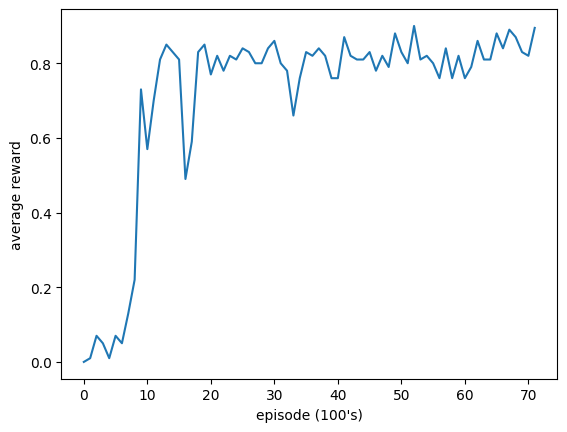

In [87]:
# we can plot the training progress and see how the agent improved
import matplotlib.pyplot as plt

def get_average(values):
    return sum(values)/len(values)

avg_rewards = []
for i in range(0, len(rewards), 100):
    avg_rewards.append(get_average(rewards[i:i+100]))

plt.plot(avg_rewards)
plt.ylabel('average reward')
plt.xlabel('episode (100\'s)')
plt.show()